<img src="./Imagenes/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos II

# Trabajo semanal 1
#### Lucas Gallero
----

# Enunciado:

Dado el siguiente circuito:

<div align="center">
    <img src="./Imagenes/enunciado.png" alt="Enunciado" width="600"/>
</div>

1. Obtener analíticamente la función transferencia $T(s)=\frac{V_2(s)}{V_1(s)}$. Realizar diagramas de módulo, fase y de polos y ceros para el caso en el que $\frac{R_2}{R_1}=1$.

2. ¿De qué tipo de filtro se trata? Investigue y comente brevemente qué utilidad podría tener este tipo de circuitos.

3. Proponga una norma de impedancia $\Omega_z$ y frecuencia $\Omega_{\omega}$ de forma tal de llegar a una transferencia **normalizada** (escalada en impedancia y frecuencia).

4. Simule numéricamente la **función transferencia normalizada** en Python.

5. Obtener una **red normalizada** que responda a la función hallada en el inciso anterior.

6. Simule la **red normalizada** en LTspice, y obtenga su respuesta en frecuencia.

**Bonus:**

- +1 💎 Verifique los resultados de los incisos 1. y 3. mediante el módulo de simulación simbólica **SymPy**.
- +1 🤯 Analice similitudes y diferencias con ambas redes del ejercicio 07 del apartado **"Amplificadores OPAMP y OTA"** de la guía de TPs.
- +1 🎓Presentación en Jupyter Notebook.

In [2]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp
from sympy.abc import s
from scipy import signal


# las librerías que usarremos las cargamos solo una vez.


# Resolución


### 1.1) Obtención Función Transferencia

Para obtener la función transferencia del circuito se aplicó el método sistemático por nodos, suponiendo al amplificador operacional ideal y trabajando en régimen lineal. Bajo estas condiciones se cumple que:

* La corriente de entrada en ambos terminales del AO es nula,
* La tensión en la entrada inversora y no inversora es la misma.

Se define entonces una tensión de nodo común:
$$
V_T = V^+ = V^-
$$

Para el análisis mediante el método de nodos, se tomarán como nodos de estudio los correspondientes a las entradas inversora y no inversora del amplificador operacional.


$$
\text{(V-)} \qquad
V_T\left(\frac{1}{R_1}+\frac{1}{R_2}\right)-\frac{V_1}{R_1}-\frac{V_2}{R_2}=0
\tag{1}
$$


$$
\text{(V+)} \qquad
V_T\left(
sC+\frac{1}{R_3}\right)-V_1sC=0
\tag{2}
$$

**Despejo $V_T$ de (2):**

$$
V_T\left(\frac{sCR_3+1}{R_3}\right)=V_1sC
$$

$$
\boxed{V_T = V_1\left(\frac{sCR_3}{sCR_3+1}\right)}
\tag{3}
$$



**Reemplazo (3) en (1):**

$$
\left( V_1 \frac{sC_1R_3}{1+sC_1R_3} \right)\left(\frac{1}{R_1}+\frac{1}{R_2}\right)-\frac{V_1}{R_1}-\frac{V_2}{R_2}=0
$$

$$
\left( \frac{sC_1R_3}{1+sC_1R_3} \right)\left(\frac{1}{R_1}+\frac{1}{R_2}\right)-\frac{1}{R_1}-\frac{V_2}{V_1R_2}=0
$$

$$
\frac{V_2}{V_1R_2}=\left( \frac{sC_1R_3}{1+sC_1R_3} \right)\left(\frac{1}{R_1}+\frac{1}{R_2}\right)-\frac{1}{R_1}
$$

$$
\frac{V_2}{V_1}=R_2\left[\left( \frac{sC_1R_3}{1+sC_1R_3} \right)\left(\frac{1}{R_1}+\frac{1}{R_2}\right)-\frac{1}{R_1}\right]
$$

$$
\frac{V_2}{V_1}= \left( \frac{sC_1R_3}{1+sC_1R_3} \right)\left(\frac{R_2}{R_1}+1\right)-\frac{R_2}{R_1}
$$

$$
\frac{V_2}{V_1}= \frac{sC_1R_3\left(\frac{R_2}{R_1}+1\right)-\frac{R_2}{R_1}(1+sC_1R_3)}{1+sC_1R_3}
$$

$$
\frac{V_2}{V_1}= \frac{sC_1R_3-\frac{R_2}{R_1}}{1+sC_1R_3}
$$

$$
\boxed{T(s) =\frac{V_2}{V_1}= \frac{s-\frac{R_2}{R_1R_3C1}}{s+\frac{1}{R_3C1}}}
$$


#### Verificación de Función Transferencia por Simulación

In [11]:
V1, V2, Vx = sp.symbols("V1, V2, Vx")
Y1, Y2, Y3, YC, Y, C1, R1, R2, R3 = sp.symbols("Y1, Y2, Y3, YC, Y, C1, R1, R2, R3")

sistema = sp.solve([ 
                    Vx*(Y1+Y2)-V1*Y1-V2*Y2,
                    Vx*(YC+Y3)-V1*YC
            ], 
            [V1,V2,Vx])

transf_func = sistema[V2]/sistema[V1]
transf_func = sp.simplify(transf_func) 

tf = transf_func.subs(Y1,1/R1)
tf = tf.subs(Y2,1/R2)
tf = tf.subs(Y3,1/R3)
tf = tf.subs(YC,s*C1)
num = tf*(s*C1+1/R3)
den = num/tf
num = sp.monic(num)
den = sp.monic(den)
num/den

(C1*s - R2/(R1*R3))/(C1*s + 1/R3)

Reordenando algebraicamente los términos obtenidos, la función transferencia del circuito queda expresada como:
$$
\boxed{T(s) = \frac{s-\frac{R_2}{R_1R_3C1}}{s+\frac{1}{R_3C1}}}
$$

Por lo tanto, se verifica que la expresión obtenida para la transferencia es consistente con el análisis nodal realizado.

Bajo la condición $\frac{R_2}{R_1}=1$, la función transferencia obtenida adopta la forma:
$$\boxed{T(s)=\frac{s-\frac{1}{R_3C_1}}{s+\frac{1}{R_3C_1}}}$$

---


## 1.2) Diagrama de Modulo, Fase, Polos y Ceros
### Diagrama de Polos y Ceros
A partir de la función transferencia

$$
T(s)=\frac{s-\frac{1}{R_3C_1}}{s+\frac{1}{R_3C_1}}
$$

puede analizarse la ubicación de sus polos y ceros en el plano complejo.

Se observa un cero en:

$$
s_z=\frac{1}{R_3C_1}
$$

y un polo en:

$$
s_p=-\frac{1}{R_3C_1}
$$

Ambos se encuentran ubicados sobre el eje real, uno en el semiplano derecho y el otro en el semiplano izquierdo. Además, puede verse que están a igual distancia del origen, por lo que son simétricos respecto del eje imaginario.

Esta disposición entre polo y cero es característica de una red pasa-todo de primer orden, ya que permite modificar la fase de la señal sin alterar su módulo.

<div style="text-align: center;">
  <img src="Imagenes/Diagrama de polos y ceros.png" alt="Diagrama de polos y ceros" width="400">
</div>

### Análisis del módulo
Para analizar el módulo, se evalúa la transferencia sobre el eje imaginario, es decir, tomando:
$$
s=j\omega
$$

Entonces:

$$
T(j\omega)=\frac{j\omega-\frac{1}{R_3C_1}}{j\omega+\frac{1}{R_3C_1}}
$$

El módulo resulta:

$$
|T(j\omega)|=\left|\frac{j\omega-\frac{1}{R_3C_1}}{j\omega+\frac{1}{R_3C_1}}\right|
$$

Elevando al cuadrado:

$$
|T(j\omega)|^2=
\frac{\omega^2+\left(\frac{1}{R_3C_1}\right)^2}
{\omega^2+\left(\frac{1}{R_3C_1}\right)^2}
$$

Por lo tanto:

$$
|T(j\omega)|^2=1
$$

y finalmente:

$$
\boxed{|T(j\omega)|=1}
$$

Esto indica que el módulo es constante para todas las frecuencias. Expresado en decibeles:
$$
\boxed{20\text{dB}\log_{10}(1)=0\ \text{dB}}
$$
Por lo tanto, la respuesta en módulo es una recta horizontal en 0 dB para todo el rango de frecuencias.

<div style="text-align: center;">
  <img src="Imagenes/modulo.png" alt="Respuesta en módulo" width="700">
</div>

### Análisis de la fase
La fase total de una función transferencia se obtiene a partir de la contribución angular de cada factor del numerador y del denominador. En general, si una transferencia tiene la forma

$$
T(s)=\frac{(s-z_1)(s-z_2)\cdots}{(s-p_1)(s-p_2)\cdots}
$$

al evaluarla en $s=j\omega$, la fase resulta:

$$
\angle T(j\omega)=\sum \angle(j\omega-z_i)-\sum \angle(j\omega-p_i)
$$

Esto ocurre porque, al multiplicar números complejos, sus ángulos se suman, y al dividirlos, sus ángulos se restan. Por eso los **ceros**, al estar en el numerador, aportan fase **positiva** y los **polos**, al estar en el denominador, aportan fase **negativa**

En este caso, la transferencia es:

$$
T(j\omega)=\frac{j\omega-\frac{1}{R_3C_1}}{j\omega+\frac{1}{R_3C_1}}
$$

Entonces, la fase total se escribe como:

$$
\phi(\omega)=\angle\left(j\omega-\frac{1}{R_3C_1}\right)-\angle\left(j\omega+\frac{1}{R_3C_1}\right)
$$

El término del numerador puede escribirse como

$$
-\frac{1}{R_3C_1}+j\omega
$$

por lo que se ubica en el segundo cuadrante del plano complejo. En consecuencia, su fase es:

$$
\boxed{\angle\left(j\omega-\frac{1}{R_3C_1}\right)=\pi-\arctan(\omega R_3C_1)}
$$

Por otro lado, el denominador puede escribirse como

$$
\frac{1}{R_3C_1}+j\omega
$$

y, al estar en el primer cuadrante, su fase resulta:

$$
\boxed{\angle\left(j\omega+\frac{1}{R_3C_1}\right)=\arctan(\omega R_3C_1)}
$$

Entonces, la fase total es:

$$
\phi(\omega)=\left[\pi-\arctan(\omega R_3C_1)\right]-\arctan(\omega R_3C_1)
$$

y finalmente:

$$
\boxed{\phi(\omega)=\pi-2\arctan(\omega R_3C_1)}
$$

### Metodo Grafico 

También puede realizarse un análisis aproximado de la fase mediante el método gráfico, a partir de la ubicación de los polos y los ceros en el plano complejo. Para ello, se estudia el aporte angular de cada uno sobre tres puntos de interés del eje imaginario: $\omega = 0$, $\omega = \omega_0$ y $\omega \to \infty$. A partir de estos puntos, es posible estimar la evolución de la fase total de la transferencia.

<div style="text-align: center;">
  <img src="Imagenes/MetodoGrafico_1.png" alt="MetodoGrafico_1" width="400">
</div>

Para $\omega = 0$ :
<div style="text-align: center;">
  <img src="Imagenes/MetodoGrafico_2.png" alt="MetodoGrafico_2" width="400">
</div>

En $\omega = 0$, el vector asociado al cero aporta un ángulo de $180^\circ$, mientras que el vector asociado al polo aporta $0^\circ$. Por lo tanto, la fase total en ese punto es:

$$
\phi(0)=180^\circ-0^\circ=180^\circ=\pi
$$

Para $\omega = \omega_0$ :
<div style="text-align: center;">
  <img src="Imagenes/MetodoGrafico_3.png" alt="MetodoGrafico_3" width="400">
</div>

En $\omega = \omega_0$, los aportes angulares resultan $135^\circ$ para el cero y $45^\circ$ para el polo. En consecuencia, la fase total vale:

$$
\phi(\omega_0)=135^\circ-45^\circ=90^\circ=\frac{\pi}{2}
$$

Para $\omega \to \infty$ : 
<div style="text-align: center;">
  <img src="Imagenes/MetodoGrafico_4.png" alt="MetodoGrafico_4" width="400">
</div>

Finalmente, cuando $\omega \to \infty$, tanto el cero como el polo aportan $90^\circ$. Por lo tanto, la fase total tiende a:

$$
\phi(\infty)=90^\circ-90^\circ=0^\circ
$$

De este modo, el análisis gráfico confirma que la fase decrece desde $180^\circ$ hasta $0^\circ$, pasando por $90^\circ$ en la frecuencia característica $\omega_0$, en concordancia con la expresión analítica obtenida previamente.

<div style="text-align: center;">
  <img src="Imagenes/Fase.png" alt="Respuesta Fase" width="700">
</div>


## 2) ¿De qué tipo de filtro se trata?
El circuito analizado corresponde a un **filtro pasa-todo de primer orden**. Esto se deduce de su función de transferencia:
$$
T(s)=\frac{V_2}{V_1}=\frac{s-\frac{1}{R_3 C_1}}{s+\frac{1}{R_3 C_1}}
$$
Podemos evaluar como se comporta en los extremos de frecuencias, donde se observa que:
$s \to 0$,   $T(s) \to -1$ y $s \to \infty$,   $T(s) \to 1$

Esto indica que la salida conserva la misma amplitud que la entrada, pero sufre una variación de fase que evoluciona con la frecuencia. Por eso, el comportamiento del circuito no se asocia con un filtrado en magnitud, sino con un **filtrado en fase**.

Los filtros pasa-todo resultan de gran utilidad en sistemas donde es necesario corregir, compensar o ajustar el desfase sin modificar el nivel de la señal. Se emplean, por ejemplo, en redes de compensación de fase, ecualización, instrumentación electrónica, sistemas de control y en ciertos osciladores o estructuras de procesamiento analógico. Su importancia radica en que permiten adaptar la respuesta temporal y fasorial de un sistema manteniendo inalterada la amplitud de la señal.


## 3) Transferencia Normalizada 
Para llevar la transferencia a una forma **normalizada en impedancia y frecuencia**, partimos de:

$$
T(s)=\frac{V_2}{V_1}=\frac{s-\frac{1}{R_3C_1}}{s+\frac{1}{R_3C_1}}
$$

Definimos la frecuencia característica:

$$
\omega_0=\frac{1}{R_3C_1}
$$

Entonces elegimos como **norma de frecuencia**:

$$
\Omega_{\omega}=\omega_0=\frac{1}{R_3C_1}
$$


Para la **normalización en impedancia**, se puede elegir como **norma de impedancia**:

$$
\Omega_z=R_3
$$

De este modo, la resistencia normalizada resulta:

$$
\boxed{R_{3N}=\frac{R_3}{\Omega_z}=1}
$$

y el capacitor normalizado:

$$
C_N=C_1\,\Omega_z\,\Omega_{\omega}
$$

reemplazando:

$$
\boxed{C_N=C_1\cdot R_3\cdot \frac{1}{R_3C_1}=1}
$$

Por lo tanto, una elección adecuada es:

$$
\Omega_z=R_3
\qquad ; \qquad
\Omega_{\omega}=\frac{1}{R_3C_1}
$$

y así la transferencia normalizada queda:

$$
\boxed{T(s)=\frac{s-1}{s+1}}
$$

### Verificación por Simulación 
Partiendo de las relaciones de normalización:
$$
R_{3N}=\frac{R_3}{\Omega_z}
\qquad ; \qquad
C_N=C_1\,\Omega_z\,\Omega_\omega
$$
se impusieron las condiciones:

$$
R_{3N}=1
\qquad ; \qquad
C_N=1
$$

In [11]:
R3, C1 = sp.symbols('R3 C1', positive=True)
Omega_z, Omega_w = sp.symbols(r'\Omega_z \Omega_\omega', positive=True)

# Condiciones para que R3N = 1 y CN = 1 
eq1 = sp.Eq(R3 / Omega_z, 1)
eq2 = sp.Eq(C1 * Omega_z * Omega_w, 1)

sol = sp.solve((eq1, eq2), (Omega_z, Omega_w), dict=True)

display(sp.Eq(Omega_z, sol[0][Omega_z]))
display(sp.Eq(Omega_w, sol[0][Omega_w]))

Eq(\Omega_z, R3)

Eq(\Omega_\omega, 1/(C1*R3))

## 4) Simulación Función Transferencia Normalizada

A partir de la transferencia normalizada obtenida en el punto anterior, se realizó su simulación numérica en Python empleando las funciones provistas por la cátedra para obtener la respuesta en frecuencia, el diagrama de polos y ceros y el retardo de grupo.
Como la función ya se encuentra normalizada, se tomó:
$$ \omega_0= 1   [\frac{rad}{seg} ]$$ 


In [2]:
plt.figure(1)
plt.close(1)

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

Text(0, 0.5, 'Retardo de grupo [seg]')

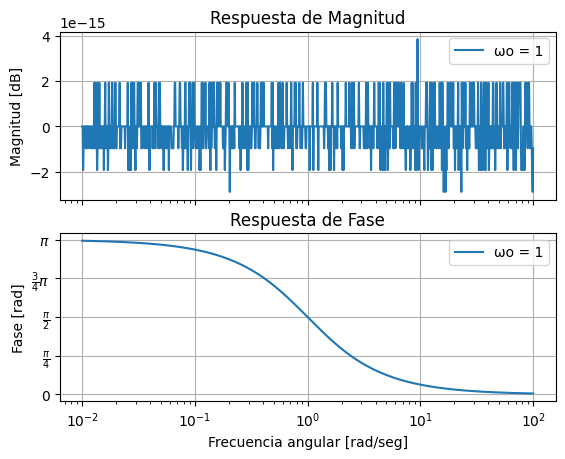

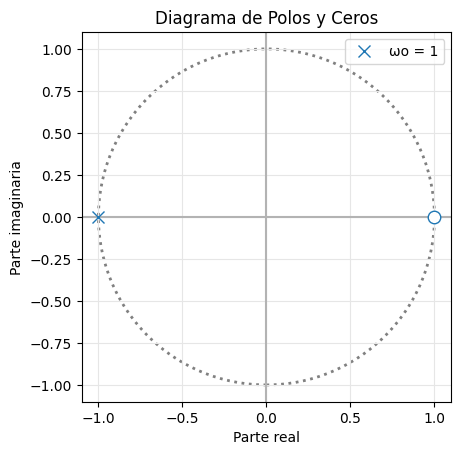

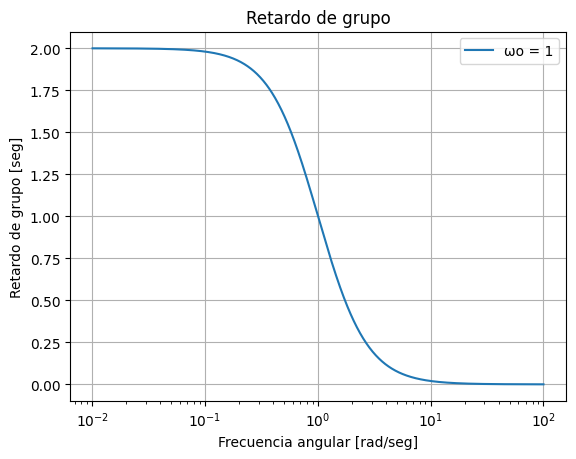

In [8]:
# Transferencia normalizada:
# T(s) = (s - 1) / (s + 1)

w0 = 1

my_tf = TransferFunction([1, -w0], [1, w0])

# Respuesta de Magnitud y Fase
bodePlot(my_tf, fig_id=1, filter_description='ωo = 1')
fig1 = plt.figure(1)
axs1 = fig1.axes

axs1[0].set_title('Respuesta de Magnitud')
axs1[1].set_title('Respuesta de Fase')
axs1[0].set_ylabel('Magnitud [dB]')
axs1[1].set_ylabel('Fase [rad]')
axs1[1].set_xlabel('Frecuencia angular [rad/seg]')

# Diagrama de Polos y Ceros
pzmap(my_tf, fig_id=2, filter_description='ωo = 1')
fig2 = plt.figure(2)
axs2 = fig2.axes
fig2._suptitle.set_text('')
axs2[0].set_title('Diagrama de Polos y Ceros')
axs2[0].set_xlabel('Parte real')
axs2[0].set_ylabel('Parte imaginaria')

# Retardo de Grupo
GroupDelay(my_tf, fig_id=3, filter_description='ωo = 1')
fig3 = plt.figure(3)
axs3 = fig3.axes

axs3[0].set_title('Retardo de grupo')
axs3[0].set_xlabel('Frecuencia angular [rad/seg]')
axs3[0].set_ylabel('Retardo de grupo [seg]')

Los resultados obtenidos muestran que el módulo permanece constante en 0 dB para toda frecuencia, mientras que la fase varía con la frecuencia. Además, el diagrama de polos y ceros presenta un cero en $s=+1$ y un polo en $s=−1$, lo cual confirma que se trata de una red pasa-todo de primer orden.

## 5) Red Normalizada 



A partir de la transferencia normalizada: 
$$ T(s)=\frac{s-1}{s+1} $$ 
se propone una red normalizada que la implemente conservando la misma topología del circuito original.

Dado que la normalización en frecuencia e impedancia se realizó tomando:
$$
\Omega_z=R_3
\qquad ; \qquad
\Omega_{\omega}=\frac{1}{R_3C_1}
$$
los valores normalizados de los componentes reactivos y resistivos asociados a la dinámica resultan:
$$
R_{3N} = 1
\qquad ; \qquad
C_N = 1
$$

Además, como para obtener la transferencia deseada debe cumplirse la condición:

$$
\frac{R_2}{R_1} = 1
$$

**Se adopta** la elección normalizada más simple:

$$
\boxed{R_{1N} = R_{2N} = 1}
$$

Por lo tanto, una red normalizada posible es:

$$
\boxed{R_{1N} = 1,\quad R_{2N} = 1,\quad R_{3N} = 1,\quad C_N = 1}
$$

la cual reproduce la transferencia normalizada:

$$
T(s) = \frac{s - 1}{s + 1}
$$

<div style="text-align: center;">
  <img src="Imagenes/RedNormalizada.png" alt="RedNormalizada" width="600">
</div>

## 6) Simulacion Red Normalizada 
La red normalizada obtenida en el punto anterior se implementó en LTspice manteniendo la topología original del circuito y adoptando los siguientes valores:
$$
\boxed{R_{1N} = 1,\quad R_{2N} = 1,\quad R_{3N} = 1,\quad C_N = 1}
$$

<div style="text-align: center;">
  <img src="Imagenes/CircuitoNormalizado.png" alt="CtoNormalizado" width="600">
</div>

Para verificar su comportamiento se realizó una simulación AC en LTspice, utilizando una fuente de entrada de amplitud unitaria y obteniendo la respuesta en frecuencia a partir del cociente:

$$ \frac{V_2}{V_1} =\frac{V_{out}}{V_{in}} $$ 

<div style="text-align: center;">
  <img src="Imagenes/Simulacion.png" alt="Simulacion
      " width="1200">
</div>

Los resultados obtenidos muestran que el módulo permanece prácticamente constante e igual a 0 dB en todo el rango de frecuencias analizado. Las pequeñas desviaciones observadas respecto de 0 dB son del orden de los microdecibeles, por lo que pueden considerarse despreciables y se deben a las limitaciones del modelo de amplificador operacional utilizado en la simulación, ya que éste no representa un dispositivo ideal.

Por otra parte, la fase presenta la variación característica de una red pasa-todo de primer orden: toma valores cercanos a $\pi$ rad para bajas frecuencias, vale aproximadamente $\pi/2$ rad en la frecuencia característica y tiende a 0 rad para frecuencias altas. Esto coincide con el comportamiento teórico esperado para la transferencia obtenida.

Cabe destacar que LTspice expresa el eje de frecuencia en Hz, mientras que la transferencia teórica está formulada en función de $s$ con frecuencia angular en rad/s. Por esta razón, la frecuencia característica normalizada $\omega_0=1\ \text{rad/s}$ corresponde en Hz a:

$$
f_0=\frac{\omega_0}{2\pi}=\frac{1}{2\pi}\approx 0.159\ \text{Hz}
$$

En conclusión, la simulación en LTspice verifica que la red normalizada implementa correctamente la transferencia teórica obtenida, confirmando tanto su módulo constante como su comportamiento de fase característico de un filtro pasa-todo de primer orden.
